# Soft / hard-sphere dilute Bose gas — results analysis

Analysis of an **SS10** equation-of-state sweep (penetrable sphere, $R=10$, scattering length $a=1$,
$N$ bosons, 3D PBC) produced by the `soft_sphere_gas` sweep machinery and stored in
`<root>/soft-hard-bosons/outputs/`.

All numbers are in **paper units** ($\hbar^2/2m=1$, $a=1$, energies in $\hbar^2/2ma^2$), so they drop
straight onto Mazzanti–Polls–Fabrocini (arXiv:cond-mat/0305502). The control parameter is the gas
parameter $x=\rho a^3$.

This notebook only **reads and analyses** an existing DB — it does not train. It reuses the shipped
machinery: `db`, `sweep.load_curve`, `analysis.plot_curve`, `dilute_gas` (Lee-Yang / $4\pi x$ / Eq.31),
and the per-run `history.csv` / `verdict.json` artifacts.

**Corridor that must hold for a converged variational run:** $4\pi x \le E/N \le E_{31}$, with
$E/N \to$ Lee-Yang as $x\to0$.


## 0. Paths & imports

The notebook lives in `<root>/qvarnet/soft_sphere_gas/` and the results live in
`<root>/soft-hard-bosons/outputs/`. Both are derived from the notebook location — edit `ROOT`
below if your layout differs.

In [1]:
from pathlib import Path
import sys, json, math, sqlite3

# --- configurable paths (defaults derived from the notebook's own location) ---
SOFT_DIR = Path.cwd()                       # .../qvarnet/soft_sphere_gas  (run the nb from here)
ROOT     = SOFT_DIR.parent.parent           # .../<root>
DATA_DIR = ROOT / 'soft-bosons-full-run' / 'outputs'
DB_PATH  = DATA_DIR / 'first-run.db'
RUNS_DIR = DATA_DIR / 'runs'

# --- which potential(s) to analyse -------------------------------------------------
# Set to ['SS10'] or ['SS5'] for a single potential, or both to OVERLAY them on one axis.
# Every load below filters the DB on potential_label, so the two are never mixed.
POT_LABELS = ['SS5', 'SS10']
POT_COLOR  = {'SS5': 'tab:orange', 'SS10': 'tab:blue'}

# make the bare-module machinery importable (db, sweep, dilute_gas, analysis, point, artifacts)
if str(SOFT_DIR) not in sys.path:
    sys.path.insert(0, str(SOFT_DIR))

assert SOFT_DIR.name == 'soft_sphere_gas', f'run this notebook from soft_sphere_gas/, not {SOFT_DIR}'
assert DB_PATH.exists(), f'DB not found: {DB_PATH}  (edit ROOT/DATA_DIR above)'
print('soft_sphere_gas :', SOFT_DIR)
print('reading results :', DATA_DIR)
print('db              :', DB_PATH)
print('potentials      :', POT_LABELS)


soft_sphere_gas : /home/pfargas/Desktop/PhD/qvarnet/soft_sphere_gas
reading results : /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs
db              : /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/first-run.db
potentials      : ['SS5', 'SS10']


In [2]:
%matplotlib inline
# ^ force the inline backend so figures render in the notebook even if MPLBACKEND=Agg is set
#   in the environment (the cluster sets it for headless runs); without this they only savefig.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import db
import sweep
import dilute_gas
import analysis
from point import Potential
import artifacts

# benchmark shorthands (paper units, a=1)
def lower_bound(x):  return 4.0 * math.pi * x                       # Lieb-Yngvason, rigorous
lee_yang = dilute_gas.lee_yang_energy_per_particle                 # Eq.1, x->0 universal limit
eq31     = dilute_gas.first_order_energy_upper_bound               # Eq.31, variational UB

# --- display thinning: keep x-points spaced >= MIN_GAP_DECADES apart in log10 x,
#     always including the first and last (purely cosmetic; does NOT touch the fits) ---
MIN_GAP_DECADES = 0.3   # ~3 points/decade; raise for fewer points (0.5->~2/dec, 1.0->~1/dec)

def thin_log(xs, min_gap_decades=MIN_GAP_DECADES):
    """Indices (into the original xs) of points spaced >= min_gap_decades in log10 x,
    always incl. the first and last. xs need not be sorted."""
    xs = np.asarray(xs, float)
    if len(xs) <= 2:
        return np.argsort(xs)
    order = np.argsort(xs)
    xs_sorted = xs[order]
    keep = [0]
    last = np.log10(xs_sorted[0])
    for i in range(1, len(xs_sorted) - 1):
        if np.log10(xs_sorted[i]) - last >= min_gap_decades:
            keep.append(i); last = np.log10(xs_sorted[i])
    keep.append(len(xs_sorted) - 1)   # always the last
    return order[keep]


## 1. Load the sweep DB

Every completed run becomes one row. We pull the scalars and unpack the convergence `verdict`
(stationarity, Geweke $z$, split-$\hat R$, epochs) into a tidy frame.

In [3]:
conn = db.connect(str(DB_PATH))
print('queue status:', db.status_counts(conn))

def _vget(vj, key, default=None):
    try: return json.loads(vj).get(key, default)
    except (TypeError, ValueError): return default

def load_runs(conn, label):
    """All done runs for one potential_label, as a tidy DataFrame (sorted by x)."""
    rows = conn.execute(
        "SELECT * FROM runs WHERE status='done' AND potential_label=? ORDER BY x, N, seed",
        (label,)).fetchall()
    recs = []
    for r in rows:
        recs.append(dict(
            x=r['x'], N=r['N'], seed=r['seed'], L=r['L'],
            e_per_n=r['e_per_n'], err=r['err_per_n'], sigma=r['sigma_e_per_n'],
            acceptance=r['acceptance'], passed=bool(r['passed']),
            upper_bound_db=r['upper_bound'],
            stationary=_vget(r['verdict_json'], 'stationary'),
            geweke_z=_vget(r['verdict_json'], 'geweke_z'),
            split_rhat=_vget(r['verdict_json'], 'split_rhat'),
            epochs=_vget(r['verdict_json'], 'epochs_ran'),
            run_dir=r['run_dir'],
        ))
    if not recs:
        return pd.DataFrame(recs)
    return pd.DataFrame(recs).sort_values('x').reset_index(drop=True)

# Per-potential workspace. Everything downstream reads from DATA[label][...].
DATA = {}
for label in POT_LABELS:
    R   = float(label[2:])                 # 'SS10' -> 10.0, 'SS5' -> 5.0 (label is f"SS{R:g}")
    pot = Potential.from_R(R, label)       # V0_paper fixed by a=1 (Eq.10)
    df  = load_runs(conn, label)
    DATA[label] = dict(R=R, V0=pot.V0_paper, pot=pot, df=df)
    print(f'{label}: {len(df)} done runs  (R={R:g}, V0={pot.V0_paper:.4e})')

# show the raw table for the first selected potential (change the index to inspect another)
display(DATA[POT_LABELS[0]]['df'])


queue status: {'done': 150}
SS5: 75 done runs  (R=5, V0=6.3086e-02)
SS10: 75 done runs  (R=10, V0=6.8167e-03)


,x,N,seed,L,e_per_n,err,sigma,acceptance,passed,upper_bound_db,stationary,geweke_z,split_rhat,epochs,run_dir
0,0.000001,32,0,317.480210,0.000012,9.116563e-07,0.000029,0.914646,False,0.000017,True,1.261928,1.000140,601,runs/SS5_x1.000e-06_N32_s0_7f2a8839
1,0.000001,32,1,317.480210,0.000012,9.143672e-07,0.000029,0.914746,False,0.000017,True,-0.065760,0.999973,401,runs/SS5_x1.000e-06_N32_s1_7f2a8839
2,0.000001,32,2,317.480210,0.000012,9.202699e-07,0.000029,0.915828,False,0.000017,True,-0.649593,0.999902,451,runs/SS5_x1.000e-06_N32_s2_7f2a8839
3,0.000001,64,0,400.000000,0.000013,6.540426e-07,0.000021,0.863199,False,0.000017,True,-0.689854,1.000004,401,runs/SS5_x1.000e-06_N64_s0_7f2a8839
4,0.000001,64,1,400.000000,0.000012,6.556444e-07,0.000021,0.864386,False,0.000017,True,-0.924357,1.000070,451,runs/SS5_x1.000e-06_N64_s1_7f2a8839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.010000,90,1,20.800838,0.152830,7.039012e-05,0.002253,0.499794,False,0.165158,True,1.167823,0.999976,351,runs/SS5_x1.000e-02_N90_s1_7f2a8839
71,0.010000,90,2,20.800838,0.152819,7.055469e-05,0.002258,0.499573,False,0.165158,True,1.026587,1.000259,351,runs/SS5_x1.000e-02_N90_s2_7f2a8839
72,0.010000,128,0,23.392142,0.152994,5.938380e-05,0.001901,0.500053,False,0.165158,True,0.039750,1.000755,351,runs/SS5_x1.000e-02_N128_s0_7f2a8839
73,0.010000,128,1,23.392142,0.152981,5.890834e-05,0.001885,0.499982,False,0.165158,True,0.676760,1.001152,351,runs/SS5_x1.000e-02_N128_s1_7f2a8839


## 2. Physics corridor check

Same test as `check_db.py`, recomputing the three benchmarks independently from `dilute_gas`:
a run is inside the corridor when $4\pi x - \mathrm{err} \le E/N \le E_{31} + \mathrm{err}$.
`E/4pix` is the ratio plotted in the paper's Fig.1 (the rigorous lower bound is the line at 1).

In [4]:
def corridor_check(df, V0, R):
    """Add benchmark columns + corridor flags for ONE potential (V0, R)."""
    chk = df.copy()
    chk['4pix']    = lower_bound(chk['x'])
    chk['LeeYang'] = chk['x'].map(lee_yang)
    chk['Eq31']    = chk['x'].map(lambda x: eq31(x, V0, R))
    chk['E/4pix']  = chk['e_per_n'] / chk['4pix']
    chk['E/LY']    = chk['e_per_n'] / chk['LeeYang']
    chk['below_lb'] = chk['e_per_n'] < chk['4pix'] - chk['err']
    chk['above_ub'] = chk['e_per_n'] > chk['Eq31'] + chk['err']
    chk['corridor_ok'] = ~(chk['below_lb'] | chk['above_ub'])
    return chk

cols = ['x','N','seed','e_per_n','err','4pix','LeeYang','Eq31','E/4pix','E/LY',
        'corridor_ok','stationary','geweke_z','split_rhat','epochs','passed']

for label in POT_LABELS:
    d = DATA[label]
    chk = corridor_check(d['df'], d['V0'], d['R'])
    d['chk'] = chk
    d['bad'] = chk[chk['stationary'] == False]          # non-stationary -> 'do not trust yet'
    n_viol = int((~chk['corridor_ok']).sum())
    print(f'[{label}] corridor violations: {n_viol}/{len(chk)}   '
          f'non-stationary: {len(d["bad"])}/{len(chk)}   '
          f'(verdict.passed: {int(chk["passed"].sum())}/{len(chk)})')

# corridor table for the first selected potential (change the index to inspect another)
_lab = POT_LABELS[0]
print(f'\ncorridor table for {_lab}:')
DATA[_lab]['chk'][cols].style.format({'e_per_n':'{:.4e}','err':'{:.2e}','4pix':'{:.4e}',
    'LeeYang':'{:.4e}','Eq31':'{:.4e}','E/4pix':'{:.3f}','E/LY':'{:.3f}',
    'geweke_z':'{:.2f}','split_rhat':'{:.4f}'})


[SS5] corridor violations: 0/75   non-stationary: 5/75   (verdict.passed: 0/75)
[SS10] corridor violations: 3/75   non-stationary: 15/75   (verdict.passed: 0/75)

corridor table for SS5:


,x,N,seed,e_per_n,err,4pix,LeeYang,Eq31,E/4pix,E/LY,corridor_ok,stationary,geweke_z,split_rhat,epochs,passed
0,0.000001,32,0,1.2277e-05,9.12e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.977,0.972,True,True,1.26,1.0001,601,False
1,0.000001,32,1,1.2295e-05,9.14e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.978,0.974,True,True,-0.07,1.0000,401,False
2,0.000001,32,2,1.2363e-05,9.20e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.984,0.979,True,True,-0.65,0.9999,451,False
3,0.000001,64,0,1.2571e-05,6.54e-07,1.2566e-05,1.2627e-05,1.6516e-05,1.000,0.996,True,True,-0.69,1.0000,401,False
4,0.000001,64,1,1.2498e-05,6.56e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.995,0.990,True,True,-0.92,1.0001,451,False
5,0.000001,64,2,1.2475e-05,6.46e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.993,0.988,True,True,-0.66,1.0000,351,False
6,0.000001,85,0,1.2522e-05,5.70e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.996,0.992,True,True,-0.65,1.0000,451,False
7,0.000001,85,1,1.2472e-05,5.77e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.992,0.988,True,True,-0.14,1.0001,351,False
8,0.000001,85,2,1.2581e-05,5.71e-07,1.2566e-05,1.2627e-05,1.6516e-05,1.001,0.996,True,True,-0.97,1.0001,351,False
9,0.000001,90,0,1.2514e-05,5.54e-07,1.2566e-05,1.2627e-05,1.6516e-05,0.996,0.991,True,True,0.28,0.9998,351,False


## 3. Equation of state — $E/N$ vs $x$ with benchmarks

`sweep.load_curve` aggregates seeds per $x$. **Note:** every run here has `passed=False`
(the early-stop target was 0, never satisfied — not a physics failure), so we pass
`require_passed=False` to include them. We mark non-stationary points so they aren't read as
physics. Left: paper's Fig.1 axis $E/N \div 4\pi x$; right: absolute $E/N$ (log-log).

saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/combined_equation_of_state.png


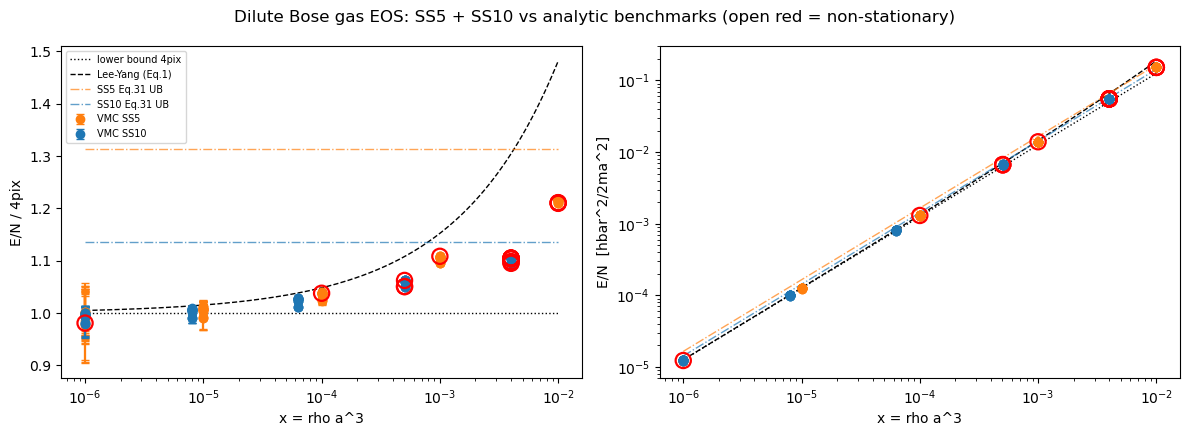

In [5]:
# Equation of state, E/N vs x. Universal benchmarks (4pix lower bound, Lee-Yang)
# are drawn once; the Eq.31 upper bound and the VMC points are drawn per potential.
xmin = min(DATA[l]['chk']['x'].min() for l in POT_LABELS)
xmax = max(DATA[l]['chk']['x'].max() for l in POT_LABELS)
xs   = np.geomspace(xmin, xmax, 200)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, scaled in [(axL, True), (axR, False)]:
    norm_s = (4*math.pi*xs) if scaled else 1.0
    ax.plot(xs, lower_bound(xs)/norm_s, 'k:',  lw=1, label='lower bound 4pix')
    ax.plot(xs, np.array([lee_yang(x) for x in xs])/norm_s, 'k--', lw=1, label='Lee-Yang (Eq.1)')

for label in POT_LABELS:
    d = DATA[label]; chk = d['chk']; bad = d['bad']; c = POT_COLOR.get(label)
    for ax, scaled in [(axL, True), (axR, False)]:
        norm   = (4*math.pi*chk['x']) if scaled else 1.0
        norm_s = (4*math.pi*xs)       if scaled else 1.0
        ax.plot(xs, np.array([eq31(x, d['V0'], d['R']) for x in xs])/norm_s,
                color=c, lw=1, ls='-.', alpha=0.7, label=f'{label} Eq.31 UB')
        ax.errorbar(chk['x'], chk['e_per_n']/norm, yerr=chk['err']/norm, fmt='o',
                    color=c, capsize=3, label=f'VMC {label}')
        if len(bad):
            nb_ = (4*math.pi*bad['x']) if scaled else 1.0
            ax.scatter(bad['x'], bad['e_per_n']/nb_, s=120, facecolors='none',
                       edgecolors='red', linewidths=1.6, zorder=5)

for ax in (axL, axR):
    ax.set_xscale('log'); ax.set_xlabel('x = rho a^3')
axL.set_ylabel('E/N / 4pix'); axR.set_ylabel('E/N  [hbar^2/2ma^2]'); axR.set_yscale('log')
axL.legend(fontsize=7)
fig.suptitle(f"Dilute Bose gas EOS: {' + '.join(POT_LABELS)} vs analytic benchmarks "
             "(open red = non-stationary)")
fig.tight_layout()
out = DATA_DIR / (f'{POT_LABELS[0].lower()}_equation_of_state.png' if len(POT_LABELS)==1
                  else 'combined_equation_of_state.png')
fig.savefig(out, dpi=140); print('saved', out)
display(fig); plt.close(fig)


## 4. Beyond-mean-field: is the LHY $\sqrt{x}$ correction resolved?

Mean field gives $E/N = 4\pi x\,(a_{\rm eff}/a)$, so the ratio $E/N\div4\pi x$ **is** $a_{\rm eff}/a$
if it is flat in $x$. Lee-Yang instead predicts it *rising* as $1+\tfrac{128}{15}\sqrt{x/\pi}$.
Plotting the ratio vs $\sqrt{x}$ separates the two: a horizontal band = mean-field with a renormalised
coupling; an upward slope = genuine LHY. (A flat ratio is the expected signature of a DeepSet ansatz
with **no pairwise Jastrow / correlation hole**.)

[SS5] weighted-mean E/N / 4pix = a_eff/a = 1.2010 +/- 0.0002   (70 stationary points)
[SS10] weighted-mean E/N / 4pix = a_eff/a = 1.0816 +/- 0.0001   (60 stationary points)
saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/combined_lhy_ratio.png


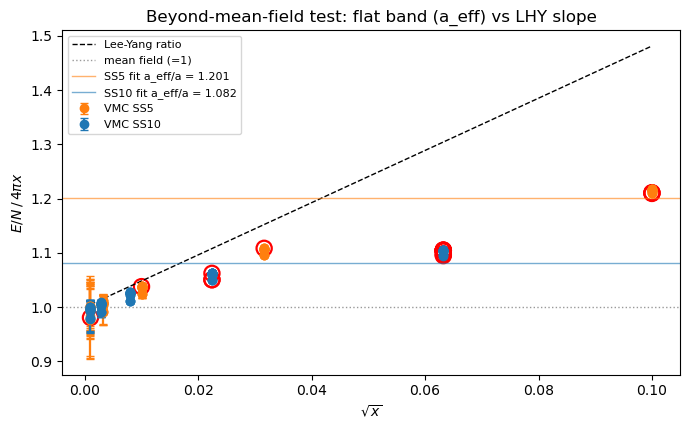

In [6]:
# Beyond-mean-field test: E/N / 4pix vs sqrt(x). A flat band -> renormalised a_eff;
# the LHY slope is the dashed reference. One weighted-mean fit per potential.
xmin = min(DATA[l]['chk']['x'].min() for l in POT_LABELS)
xmax = max(DATA[l]['chk']['x'].max() for l in POT_LABELS)
xx = np.linspace(xmin, xmax, 200)

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(np.sqrt(xx), 1 + (128/15)*np.sqrt(xx/math.pi), 'k--', lw=1, label='Lee-Yang ratio')
ax.axhline(1.0, color='0.6', ls=':', lw=1, label='mean field (=1)')

for label in POT_LABELS:
    d = DATA[label]; chk = d['chk']; bad = d['bad']; c = POT_COLOR.get(label)
    good  = chk[chk['stationary'] != False]            # stationary points only for the fit
    ratio = good['E/4pix'].to_numpy()
    w     = 1.0 / (good['err'].to_numpy() / good['4pix'].to_numpy())**2
    a_eff     = float(np.sum(w*ratio) / np.sum(w))
    a_eff_err = float(np.sqrt(1.0 / np.sum(w)))
    d['a_eff'], d['a_eff_err'] = a_eff, a_eff_err
    print(f'[{label}] weighted-mean E/N / 4pix = a_eff/a = {a_eff:.4f} +/- {a_eff_err:.4f} '
          f'  ({len(good)} stationary points)')
    ax.errorbar(np.sqrt(chk['x'].to_numpy()), chk['E/4pix'], yerr=chk['err']/chk['4pix'],
                fmt='o', color=c, capsize=3, label=f'VMC {label}')
    if len(bad):
        ax.scatter(np.sqrt(bad['x']), bad['e_per_n']/bad['4pix'], s=120, facecolors='none',
                   edgecolors='red', linewidths=1.6)
    ax.axhline(a_eff, color=c, lw=1, alpha=0.6, label=f'{label} fit a_eff/a = {a_eff:.3f}')

ax.set_xlabel(r'$\sqrt{x}$'); ax.set_ylabel(r'$E/N \,/\, 4\pi x$')
ax.set_title('Beyond-mean-field test: flat band (a_eff) vs LHY slope')
ax.legend(fontsize=8); fig.tight_layout()
out = DATA_DIR / (f'{POT_LABELS[0].lower()}_lhy_ratio.png' if len(POT_LABELS)==1
                  else 'combined_lhy_ratio.png')
fig.savefig(out, dpi=140); print('saved', out)
display(fig); plt.close(fig)


## 5. Per-run convergence (history.csv)

$E/N$ vs epoch for each run, straight from the artifacts. Non-stationary runs (red) are still
drifting at the last epoch — those points need more epochs (or `sampler='pt'`) before they enter
any physics figure.

saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/combined_convergence.png


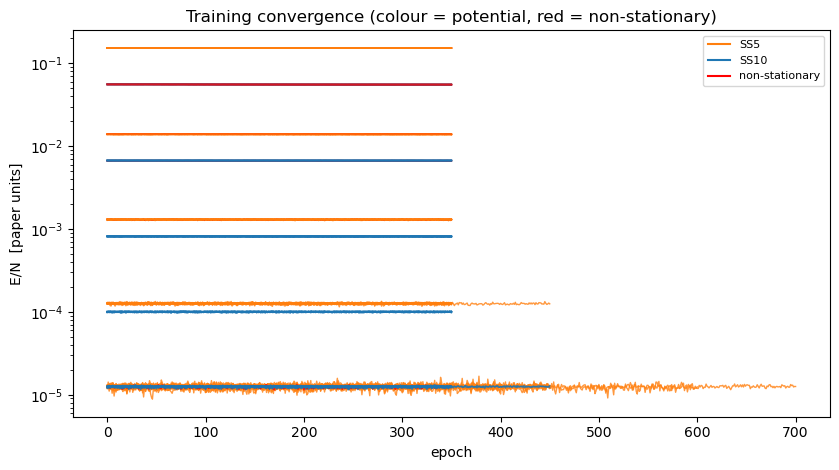

In [7]:
# Per-run training convergence (history.csv). Colour = potential, red = non-stationary.
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for label in POT_LABELS:
    d = DATA[label]; c = POT_COLOR.get(label)
    for _, row in d['chk'].iterrows():
        rd = RUNS_DIR / Path(row['run_dir']).name
        hist = rd / 'history.csv'
        if not hist.exists():
            print('missing', hist); continue
        h = pd.read_csv(hist)
        nonstat = (row['stationary'] == False)
        ax.plot(h['epoch'], h['e_per_n_paper'], lw=1.0, alpha=0.8,
                color=('red' if nonstat else c))
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('E/N  [paper units]')
ax.set_title('Training convergence (colour = potential, red = non-stationary)')
handles = [mlines.Line2D([], [], color=POT_COLOR.get(l), label=l) for l in POT_LABELS]
handles.append(mlines.Line2D([], [], color='red', label='non-stationary'))
ax.legend(handles=handles, fontsize=8)
fig.tight_layout()
out = DATA_DIR / (f'{POT_LABELS[0].lower()}_convergence.png' if len(POT_LABELS)==1
                  else 'combined_convergence.png')
fig.savefig(out, dpi=140); print('saved', out)
display(fig); plt.close(fig)


## 6. Thermodynamic limit — $N\to\infty$ extrapolation at fixed $x$

At fixed gas parameter $x$, the finite-box $E/N$ carries a leading $O(1/N)$ finite-size correction,
so a **weighted linear fit of $E/N$ vs $1/N$** extrapolates to the thermodynamic value $E_\infty$ —
the number that lands on the paper's curve. `analysis.extrapolate_thermodynamic` aggregates the
seeds per $(x,N)$ (mean $E/N$, conservative error) and fits per $x$; only $x$ sampled at $\ge 2$
values of $N$ can be extrapolated. (A per-$N$ grid leaves few $x$ overlapping across $N$; the
**aligned** sweep gives all $N$ at every $x$, so this section fills out fully there.)

Below: the per-$x$ fit panels ($E/N$ vs $1/N$, red square $= 1/N\to0$), then $E_\infty(x)$ on the
benchmark corridor (grey $=$ the finite-$N$ points it was extrapolated from).

[SS5] N ladder = [32, 64, 85, 90, 128];  extrapolated 5 x-point(s) with >=2 N
  SS5 extrapolation table:


,x,n_N,E_inf,E_inf_err,slope_per_1/N,E_inf/4pix,E_inf/LY
0,1.000e-06,5,1.26491e-05,5.96e-07,-1.017e-05,1.007,1.002
1,1.000e-05,5,1.27894e-04,1.92e-06,-1.059e-04,1.018,1.002
2,1.000e-04,5,1.31272e-03,6.26e-06,-7.916e-04,1.045,0.997
3,1.000e-03,5,1.39821e-02,2.13e-05,-6.374e-03,1.113,0.966
4,1.000e-02,5,1.53270e-01,9.21e-05,-3.849e-02,1.220,0.823


saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/ss5_extrapolation.png


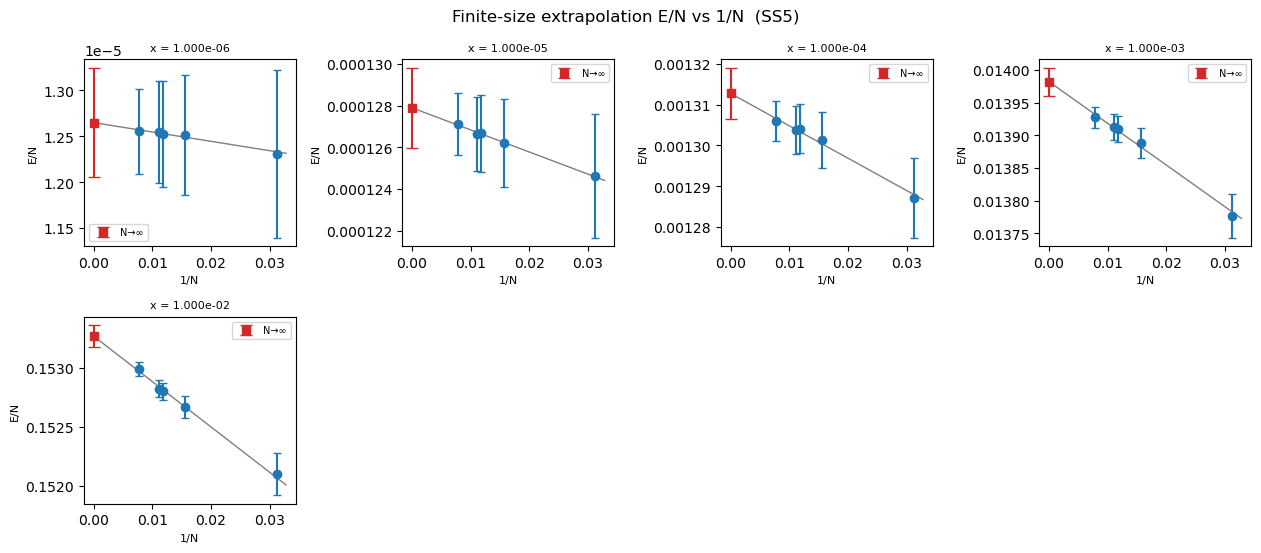

[SS10] N ladder = [32, 64, 85, 90, 128];  extrapolated 5 x-point(s) with >=2 N
  SS10 extrapolation table:


,x,n_N,E_inf,E_inf_err,slope_per_1/N,E_inf/4pix,E_inf/LY
0,1.000e-06,5,1.26423e-05,2.08e-07,-1.048e-05,1.006,1.001
1,7.951e-06,5,1.01410e-04,5.92e-07,-7.857e-05,1.015,1.001
2,6.321e-05,5,8.21316e-04,1.71e-06,-5.564e-04,1.034,0.996
3,5.026e-04,5,6.74612e-03,5.54e-06,-3.439e-03,1.068,0.964
4,3.996e-03,5,5.55566e-02,3.13e-05,-1.065e-02,1.106,0.848


saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/ss10_extrapolation.png


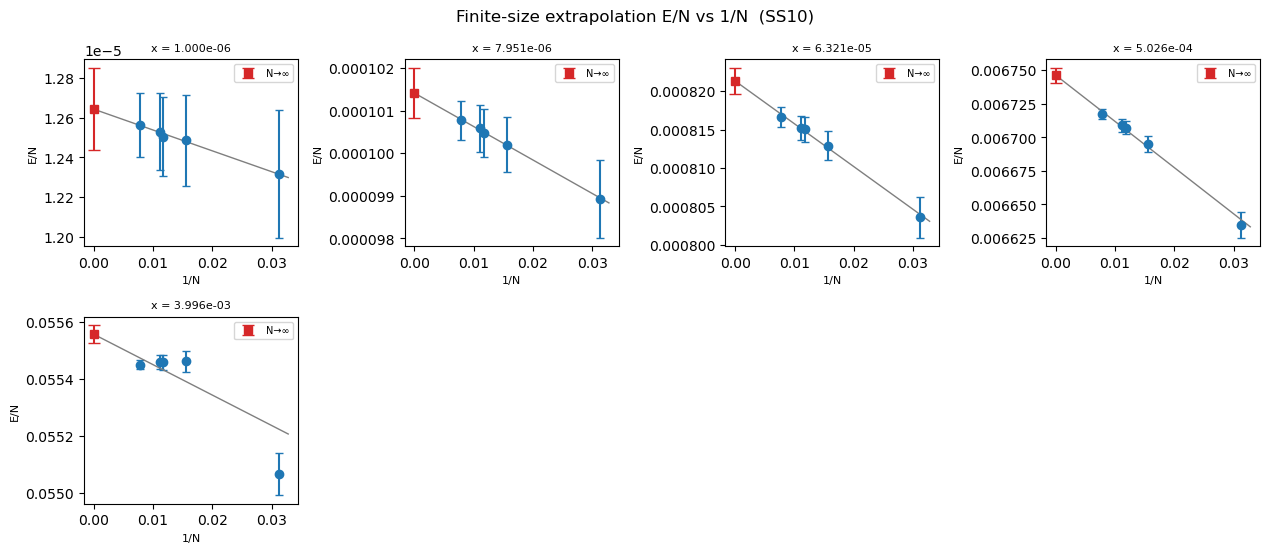

In [8]:
# N -> infinity extrapolation at fixed x (one panel grid per potential).
for label in POT_LABELS:
    d = DATA[label]; df = d['df']
    N_list = sorted(int(n) for n in df['N'].unique())
    fits = analysis.extrapolate_thermodynamic(conn, label, N_list, require_passed=False)
    d['fits'], d['N_list'] = fits, N_list
    print(f'[{label}] N ladder = {N_list};  extrapolated {len(fits)} x-point(s) with >=2 N')
    if not fits:
        continue
    ext = pd.DataFrame([
        {'x': x, 'n_N': f['n_points'], 'E_inf': f['e_inf'], 'E_inf_err': f['e_inf_err'],
         'slope_per_1/N': f['slope'],
         'E_inf/4pix': f['e_inf']/lower_bound(x), 'E_inf/LY': f['e_inf']/lee_yang(x)}
        for x, f in sorted(fits.items())])
    print(f'  {label} extrapolation table:')
    display(ext.style.format({'x':'{:.3e}','E_inf':'{:.5e}','E_inf_err':'{:.2e}',
        'slope_per_1/N':'{:+.3e}','E_inf/4pix':'{:.3f}','E_inf/LY':'{:.3f}'}))
    save = DATA_DIR / f'{label.lower()}_extrapolation.png'
    fig = analysis.plot_extrapolations(fits, d['pot'], scaled=False, save=save)
    display(fig); plt.close(fig)


saved /home/pfargas/Desktop/PhD/soft-bosons-full-run/outputs/combined_eos_thermodynamic.png


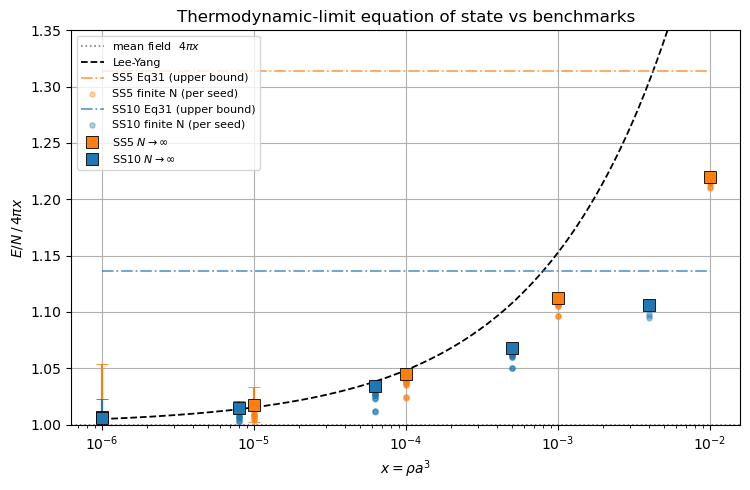

In [12]:
# Thermodynamic-limit EOS on the E/N / 4pix axis vs analytic benchmarks.
# Universal curves drawn once; Eq.31 UB + extrapolated N->inf points drawn per potential.
x_all = np.array([1e-6, 1e-2])
xx = np.geomspace(x_all.min(), x_all.max(), 300)

fig, ax = plt.subplots(figsize=(7.6, 5.0))
ax.axhline(1.0, color='0.5', ls=':', lw=1.2, label=r'mean field  $4\pi x$')
ax.plot(xx, [lee_yang(x) / lower_bound(x) for x in xx], 'k--', lw=1.3, label='Lee-Yang')

for label in POT_LABELS:
    d = DATA[label]; chk = d['chk']; fits = d.get('fits', {}); c = POT_COLOR.get(label)
    ax.plot(xx, [eq31(x, d['V0'], d['R']) / lower_bound(x) for x in xx], color=c, lw=1.3,
            ls='-.', alpha=0.7, label=f'{label} Eq31 (upper bound)')
    if fits:
        xs_e = np.array(sorted(fits))
        keep = xs_e[thin_log(xs_e)]                   # thin in log-x: keep 1st & last
        e_inf     = np.array([fits[x]['e_inf']     for x in keep])
        e_inf_err = np.array([fits[x]['e_inf_err'] for x in keep])
        chk_show  = chk[chk['x'].isin(set(keep))]
        ax.scatter(chk_show['x'], chk_show['E/4pix'], s=14, color=c, alpha=0.35, zorder=2,
                   label=f'{label} finite N (per seed)')
        ax.errorbar(keep, e_inf / lower_bound(keep), yerr=e_inf_err / lower_bound(keep), fmt='s',
                    color=c, mec='k', mew=0.6, ms=8, capsize=4, zorder=6,
                    label=fr'{label} $N\to\infty$')
    else:
        ax.scatter(chk['x'], chk['E/4pix'], s=14, color=c, alpha=0.35, zorder=2,
                   label=f'{label} finite N (per seed)')

ax.set_xscale('log')
ax.set_xlabel(r'$x = \rho a^3$'); ax.set_ylabel(r'$E/N \,/\, 4\pi x$')
ax.set_title('Thermodynamic-limit equation of state vs benchmarks')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True); ax.set_ylim(1.0, 1.35)
fig.tight_layout()
out = DATA_DIR / (f'{POT_LABELS[0].lower()}_eos_thermodynamic.png' if len(POT_LABELS)==1
                  else 'combined_eos_thermodynamic.png')
fig.savefig(out, dpi=140); print('saved', out)
display(fig); plt.close(fig)


## 7. Findings & next steps

*(auto-summary from the cells above; edit after inspecting the figures)*

In [10]:
for label in POT_LABELS:
    d = DATA[label]; chk = d['chk']
    n_done = len(chk); n_stat = int((chk['stationary'] != False).sum())
    print(f'{label} sweep summary')
    print('-'*60)
    print(f'points (done)        : {n_done}   x in [{chk["x"].min():.2e}, {chk["x"].max():.2e}]')
    print(f'inside corridor      : {int(chk["corridor_ok"].sum())}/{n_done}')
    print(f'stationary           : {n_stat}/{n_done}')
    if 'a_eff' in d:
        print(f'weighted-mean E/4pix : {d["a_eff"]:.4f} +/- {d["a_eff_err"]:.4f}  '
              '(only meaningful if ~flat in x)')
    nonstat = chk[chk['stationary'] == False]
    if len(nonstat):
        print('non-stationary points to re-run (more epochs / sampler=pt):')
        for _, b in nonstat.iterrows():
            print(f"   x={b['x']:.3e}  geweke_z={b['geweke_z']:.2f}  epochs={b['epochs']}")
    print()

print('Interpretation:')
print(' - E/N inside [4pix, Eq31] -> variationally consistent.')
print(' - With the soft-core Jastrow ON, E/N tracks Lee-Yang at low x; compare the')
print('   N->inf extrapolation (section 6) to DMC / the paper curve.')
print(' - At low x mean-field ~ Lee-Yang ~ 4pix, so the corridor is a WEAK test there;')
print('   the real validation is the extrapolated E_inf(x) landing on the curve.')


SS5 sweep summary
------------------------------------------------------------
points (done)        : 75   x in [1.00e-06, 1.00e-02]
inside corridor      : 75/75
stationary           : 70/75
weighted-mean E/4pix : 1.2010 +/- 0.0002  (only meaningful if ~flat in x)
non-stationary points to re-run (more epochs / sampler=pt):
   x=1.000e-04  geweke_z=2.97  epochs=351
   x=1.000e-03  geweke_z=-2.40  epochs=351
   x=1.000e-02  geweke_z=1.66  epochs=351
   x=1.000e-02  geweke_z=7.83  epochs=351
   x=1.000e-02  geweke_z=4.57  epochs=351

SS10 sweep summary
------------------------------------------------------------
points (done)        : 75   x in [1.00e-06, 4.00e-03]
inside corridor      : 72/75
stationary           : 60/75
weighted-mean E/4pix : 1.0816 +/- 0.0001  (only meaningful if ~flat in x)
non-stationary points to re-run (more epochs / sampler=pt):
   x=1.000e-06  geweke_z=-0.73  epochs=351
   x=5.026e-04  geweke_z=1.65  epochs=351
   x=5.026e-04  geweke_z=2.00  epochs=351
   x=5.026